# Stroke Prediction

Podstawowa struktura notebooka do projektu klasyfikacji ryzyka udaru.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, GridSearchCV
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import(
    recall_score,
    precision_score,
    fbeta_score,
    roc_auc_score,
    average_precision_score,
    make_scorer,
    confusion_matrix
)

## 1. Cel i zakres

- Zdefiniuj problem i zmienną celu (`stroke`).
- Opisz krótko dane i metryki, których będziesz używać.

## 2. Środowisko i konfiguracja

- Opisz użyte biblioteki i wersje.
- Zapisz założenia dotyczące powtarzalności (np. random seed).
- Dodaj krótką notatkę o strukturze notebooka.

## 3. Wczytanie i opis danych

- Źródło danych.
- Wymiary zbioru i opis kolumn.
- Typy zmiennych (numeryczne / kategoryczne).
- Krótki komentarz o jakości danych.

In [2]:
try:
    df = pd.read_csv('../data/healthcare-dataset-stroke-data.csv', index_col=0)
except FileNotFoundError:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    path = '/content/drive/MyDrive/datasets/healthcare-dataset-stroke-data.csv'
    df = pd.read_csv(path)
df.shape

(5110, 11)

Dane zostały wzięte z ogólno dostępnego zbioru danych na kaggle - *Stroke Prediction Dataset*. Zbiór danych zawiera 11 atrybutów (z czego jedna opisuje czy pacjent miał zawał) oraz 5110 pacjentów.

In [3]:
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
id,,,,,,,,,,,
9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


| Nazwa kolumny | Opis | Rodzaj danych |
|---|---|---|
| `gender` | Płeć pacjenta | Kategoryczna |
| `age` | Wiek pacjenta | Numeryczna |
| `hypertension` | Czy pacjent ma nadciśnienie | Kategoryczna (binarna) |
| `heart_disease` | Czy pacjent ma jakieś choroby serca | Kategoryczna (binarna) |
| `ever_married` | Czy pacjent był/jest w małżeństwie | Kategoryczna |
| `work_type` | Rodzaj pracy wykonywany | Kategoryczna |
| `Residence_type` | Miejsce zamieszkania | Kategoryczna |
| `avg_glucose_level` | Średni poziom glukozy we krwi | Numeryczna |
| `bmi` | 'Body mass index' | Numeryczna |
| `smoking_status` | Relacja pacjenta z papierosami | Kategoryczna |


In [4]:
num_cols = ['age', 'avg_glucose_level', 'bmi']
cat_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

<Axes: xlabel='stroke', ylabel='count'>

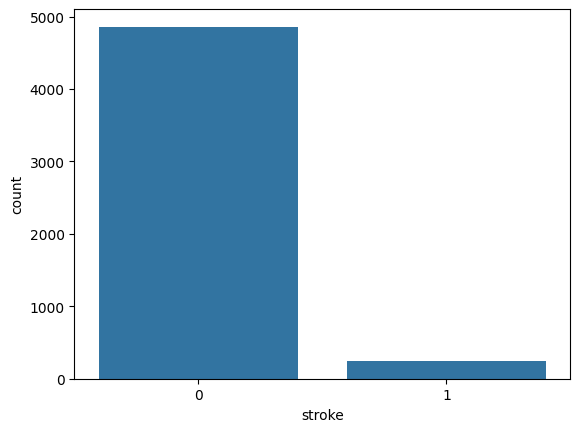

In [5]:
sns.countplot(df, x=df.stroke)

Zbiór danych jest silnie niezbalansowany, około 5% danych to przypadki pozytywne (zawał wystąpił). Do jak najleszego wytrenowania modelu będzie dobrze zrobiony podział danych.

## 4. Czyszczenie i sanity check danych

- Braki danych i strategia ich uzupełniania.
- Outliery

In [6]:
missing_values = df.isnull().sum()
missing_values

gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

Sprawdźmy jak wygląda brak BMI w kontekście tego czy ktoś miał udar czy nie

Procentowy rozklad udaru dla brakow BMI (0 = brak braku, 1 = brak BMI):


stroke,0,1
bmi_missing,,
0,95.74,4.26
1,80.10,19.90


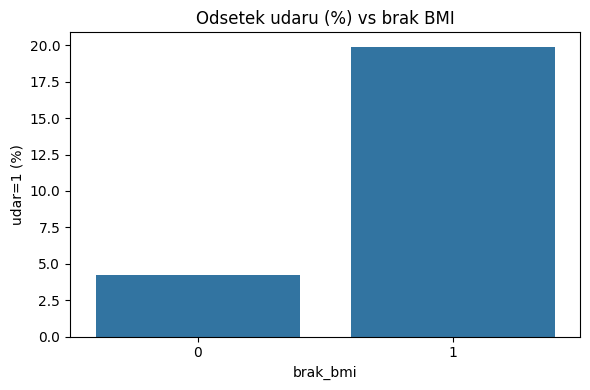

In [7]:
df_eda = df.copy()
df_eda["bmi_missing"] = df_eda["bmi"].isna().astype(int)

missing_vs_target = pd.crosstab(
    df_eda["bmi_missing"],
    df_eda["stroke"],
    normalize="index"
) * 100

print("Procentowy rozklad udaru dla brakow BMI (0 = brak braku, 1 = brak BMI):")
display(missing_vs_target.round(2))

plt.figure(figsize=(6, 4))
ax = sns.barplot(
    x=missing_vs_target.index.astype(str),
    y=missing_vs_target[1].values
)
ax.set_title("Odsetek udaru (%) vs brak BMI")
ax.set_xlabel("brak_bmi")
ax.set_ylabel("udar=1 (%)")
plt.tight_layout()
plt.show()

20% przypadków z udarem to osoby, które nie mają BMI w danych. Brakujące dane w kolumnie BMI zastąpimy medianą zbioru, ponieważ model mógłby się nauczyć, że jeżeli ta kolumna jest pusta to mamy udar.

In [8]:
df.bmi = df.bmi.transform(lambda x: x.fillna(x.median()))

In [9]:
assert df.bmi.isnull().values.any() == False, "Kolumna 'bmi' zawiera brakujące wartości"

### Sprawdzenie czy nie mamy dzikich wartości w zbiorze danych

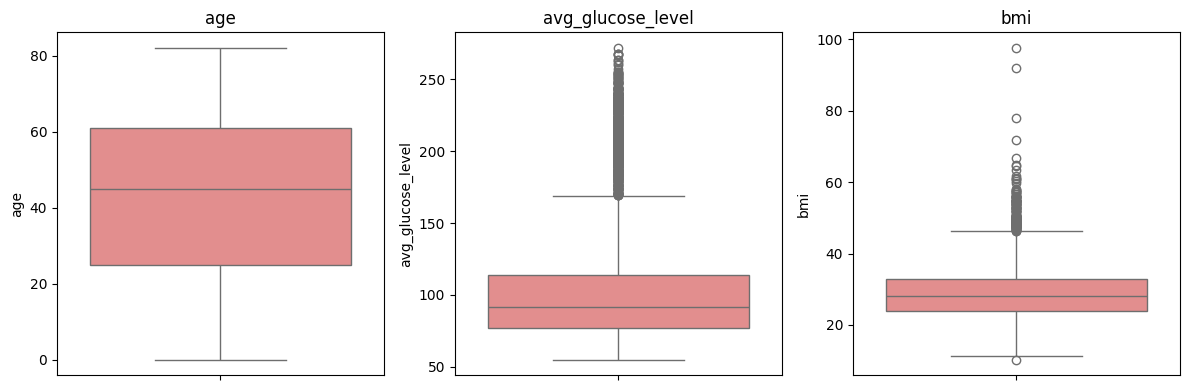

In [10]:
plt.figure(figsize=(12, 4))
for i, col in enumerate(num_cols, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=df[col], color='lightcoral')
    plt.title(f'{col}')
plt.tight_layout()
plt.show()

## 5. Eksploracyjna analiza danych (EDA)

- Rozkład zmiennej celu (`stroke`).
- Analiza cech względem celu.
- Korelacje i zależności między cechami.
- Najważniejsze obserwacje z EDA.

array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'avg_glucose_level'}>,
        <Axes: title={'center': 'bmi'}>]], dtype=object)

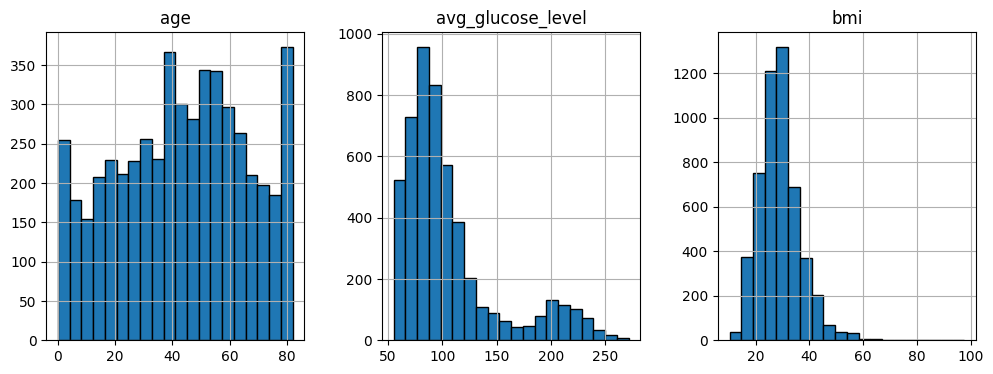

In [11]:
num_cols = ['age', 'avg_glucose_level', 'bmi']
df[num_cols].hist(figsize=(12, 4), bins=20, edgecolor='black', layout=(1,3))

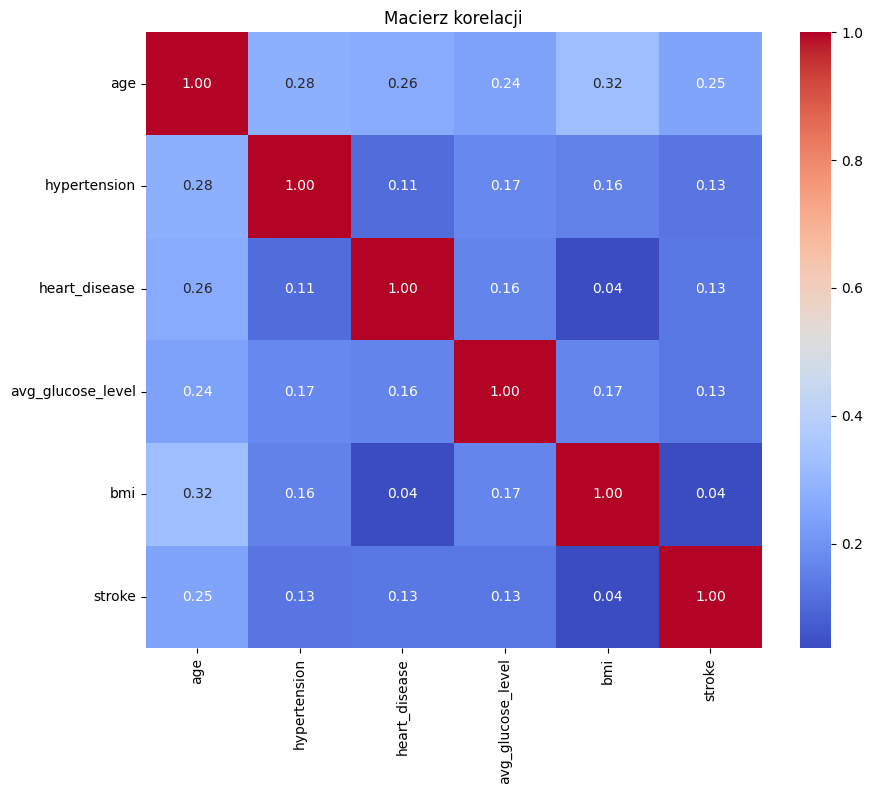

In [12]:
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title("Macierz korelacji")
plt.show()

Liczebnosci klas:


stroke
0    4861
1     249
Name: count, dtype: int64

Procenty klas:


stroke
0    95.13
1     4.87
Name: proportion, dtype: float64

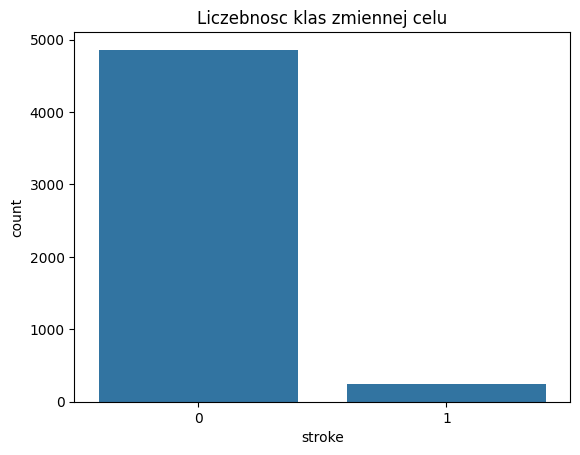

In [13]:
target_counts = df["stroke"].value_counts().sort_index()
target_pct = df["stroke"].value_counts(normalize=True).sort_index() * 100

print("Liczebnosci klas:")
display(target_counts)
print("Procenty klas:")
display(target_pct.round(2))

sns.countplot(data=df, x="stroke")
plt.title("Liczebnosc klas zmiennej celu")
plt.show()


gender -> odsetek udaru (%)


,odsetek_udaru_proc
gender,
Male,5.11
Female,4.71
Other,0.00


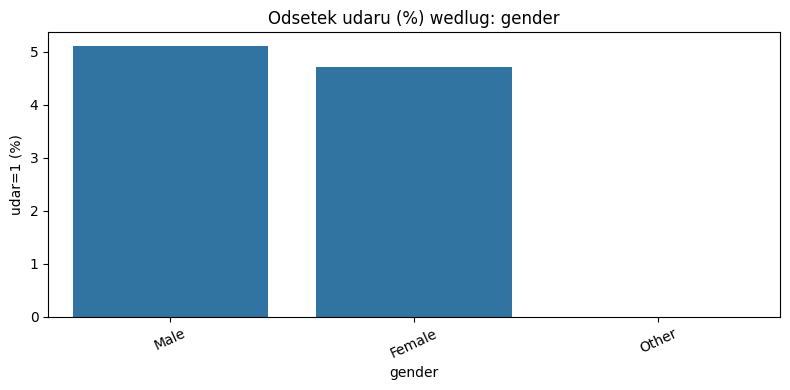


ever_married -> odsetek udaru (%)


,odsetek_udaru_proc
ever_married,
Yes,6.56
No,1.65


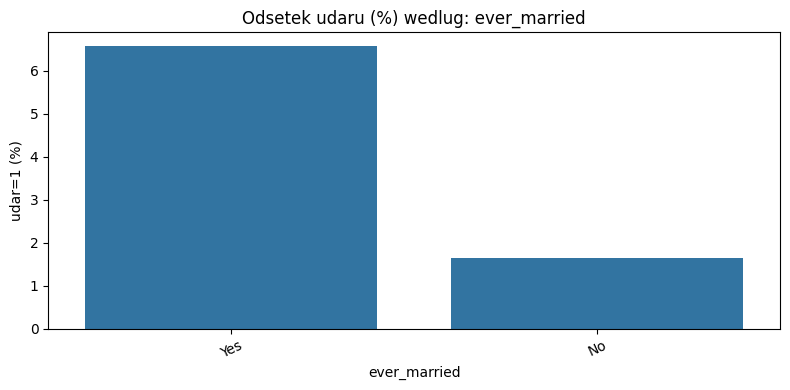


work_type -> odsetek udaru (%)


,odsetek_udaru_proc
work_type,
Self-employed,7.94
Private,5.09
Govt_job,5.02
children,0.29
Never_worked,0.00


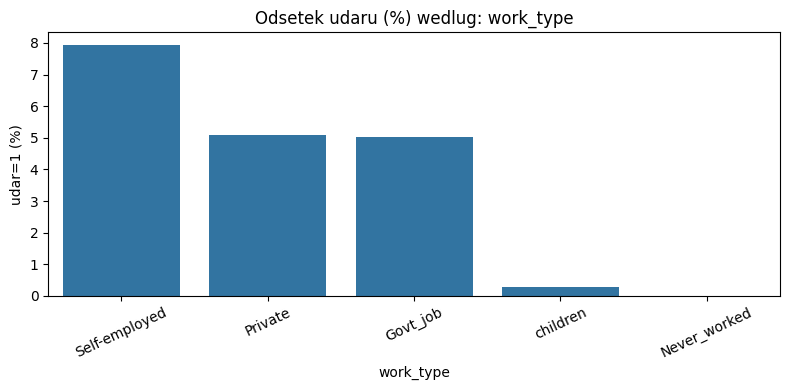


Residence_type -> odsetek udaru (%)


,odsetek_udaru_proc
Residence_type,
Urban,5.20
Rural,4.53


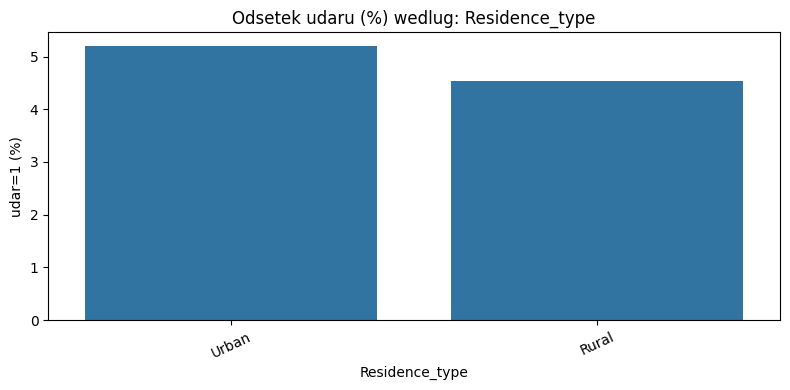


smoking_status -> odsetek udaru (%)


,odsetek_udaru_proc
smoking_status,
formerly smoked,7.91
smokes,5.32
never smoked,4.76
Unknown,3.04


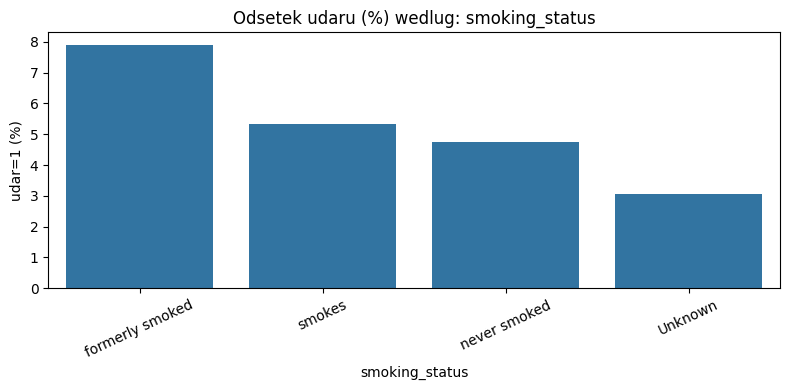

In [14]:
cat_cols_focus = ["gender", "ever_married", "work_type", "Residence_type", "smoking_status"]

for col in cat_cols_focus:
    rate = (
        df.groupby(col)["stroke"]
        .mean()
        .sort_values(ascending=False)
        * 100
    )

    print(f"\n{col} -> odsetek udaru (%)")
    display(rate.round(2).to_frame(name="odsetek_udaru_proc"))

    plt.figure(figsize=(8, 4))
    sns.barplot(x=rate.index.astype(str), y=rate.values)
    plt.title(f"Odsetek udaru (%) wedlug: {col}")
    plt.xlabel(col)
    plt.ylabel("udar=1 (%)")
    plt.xticks(rotation=25)
    plt.tight_layout()
    plt.show()

,liczebnosc,odsetek_udaru_proc
przedzial_wieku,,
0-18,916,0.22
19-30,654,0.00
31-45,1048,1.05
46-60,1188,4.97
61-75,839,9.65
76+,465,20.65


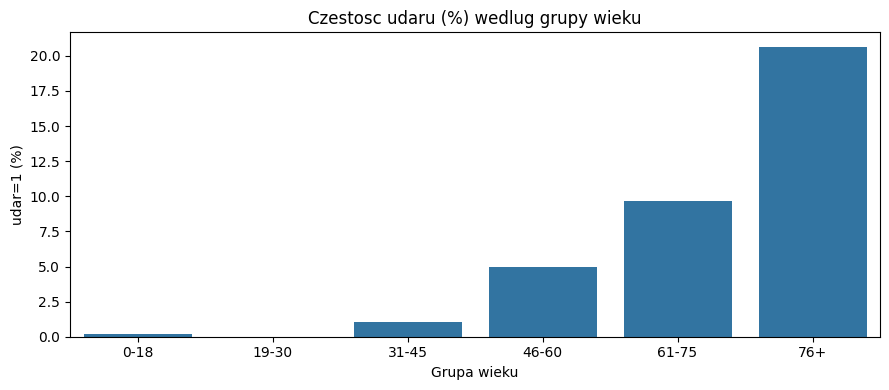

In [15]:
age_bins = [0, 18, 30, 45, 60, 75, 100]
age_labels = ["0-18", "19-30", "31-45", "46-60", "61-75", "76+"]

df_age = df.copy()
df_age["przedzial_wieku"] = pd.cut(
    df_age["age"],
    bins=age_bins,
    labels=age_labels,
    include_lowest=True,
    right=True,
)

age_stats = df_age.groupby("przedzial_wieku", observed=False).agg(
    liczebnosc=("stroke", "count"),
    odsetek_udaru_proc=("stroke", lambda s: s.mean() * 100),
)

display(age_stats.round(2))

plt.figure(figsize=(9, 4))
sns.barplot(x=age_stats.index.astype(str), y=age_stats["odsetek_udaru_proc"].values)
plt.title("Czestosc udaru (%) wedlug grupy wieku")
plt.xlabel("Grupa wieku")
plt.ylabel("udar=1 (%)")
plt.tight_layout()
plt.show()

### Wnioski z EDA

- Zmienna celu `stroke` jest silnie niezbalansowana (klasa pozytywna to niewielki odsetek danych), dlatego sama accuracy nie bedzie wystarczajaca do oceny modelu.
- Braki `bmi` niosa informacje: dla `bmi_missing=1` odsetek `stroke=1` jest wyraznie wyzszy niz dla `bmi_missing=0` (ok. `19.9%` vs `4.26%`).
- Wiek ma silny zwiazek z ryzykiem: wraz ze wzrostem grupy wiekowej rosnie odsetek `stroke=1`.
- Dla cech kategorycznych (`gender`, `ever_married`, `work_type`, `Residence_type`, `smoking_status`) widoczne sa roznice miedzy grupami, wiec warto zachowac, np. przez użycie OneHotEncoding.

## 6. Podział danych i metodologia

- Kodowanie zmiennych kategorycznych
- Skalowanie zmiennych numerycznych
- Podział na zbiory: treningowy / walidacyjny / testowy.
- Strategia walidacji (np. cross-validation).
- Metryki oceny (np. accuracy, precision, recall, F1, ROC-AUC).
- Kryteria wyboru modelu końcowego.

In [16]:
X = df.drop(columns=["stroke"]).copy()
y = df["stroke"].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

cat_cols = ["gender", "ever_married", "work_type", "Residence_type", "smoking_status"]

X_train = pd.get_dummies(X_train, columns=cat_cols, drop_first=False)
X_test = pd.get_dummies(X_test, columns=cat_cols, drop_first=False)

X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

**Dlaczego używamy SMOTE?**

Zmienna celu `stroke` jest silnie niezbalansowana (klasa pozytywna jest rzadka), co może powodować, że model będzie faworyzował klasę `0`.

SMOTE (Synthetic Minority Oversampling Technique) tworzy syntetyczne przykłady klasy mniejszościowej tylko na zbiorze treningowym, dzięki czemu model ma lepszą szansę nauczyć się wzorców dla `stroke=1` i nie ignorować przypadków pozytywnych.

Ważne: SMOTE stosujemy wyłącznie na danych treningowych (`X_train`, `y_train`), a zbiór testowy pozostaje bez zmian, aby ocena modelu była uczciwa.

In [17]:
print("Przed SMOTE:")
print(y_train.value_counts())

smote = SMOTE(random_state=67)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\nPo SMOTE:")
print(y_train_smote.value_counts())

print("X_train_smote:", X_train_smote.shape)
print("X_test:", X_test.shape)
print("y_train_smote:", y_train_smote.shape)
print("y_test:", y_test.shape)

Przed SMOTE:
stroke
0    3889
1     199
Name: count, dtype: int64

Po SMOTE:
stroke
0    3889
1    3889
Name: count, dtype: int64
X_train_smote: (7778, 21)
X_test: (1022, 21)
y_train_smote: (7778,)
y_test: (1022,)


## X. Własna metryka

In [18]:
def custom_metric(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return (tp * 1.0) + (fp * -0.25)

custom_scorer = make_scorer(custom_metric, greater_is_better=True)

## 7. Trenowanie modeli

- Model bazowy (baseline).
- Modele porównawcze.
- Strojenie hiperparametrów.
- Tabela porównawcza wyników.

### 7.1 Baseline

In [19]:
def evaluate_model(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:,1]
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_test)
    else:
        y_score = y_pred
    
    return {
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "f2": fbeta_score(y_test, y_pred, beta=2, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_score),
        "pr_auc": average_precision_score(y_test, y_score),
    }


In [20]:
baseline_models = {
    "dummy_most_frequent": DummyClassifier(strategy="most_frequent"),
    "dummy_stratified": DummyClassifier(strategy="stratified", random_state=42),
    "logreg_default": LogisticRegression(max_iter=2000, random_state=42),
}

rows = []
for name, model in baseline_models.items():
    metrics = evaluate_model(model, X_train_smote, y_train_smote, X_test, y_test)
    metrics["model"] = name
    rows.append(metrics)

baseline_results = pd.DataFrame(rows)[
    ["model", "recall", "precision", "f2", "roc_auc", "pr_auc"]
].sort_values("f2", ascending=False)

baseline_results

,model,recall,precision,f2,roc_auc,pr_auc
2,logreg_default,0.64,0.211921,0.455840,0.824403,0.194964
1,dummy_stratified,0.50,0.048924,0.175809,0.500000,0.048924
0,dummy_most_frequent,0.00,0.000000,0.000000,0.500000,0.048924


- Wnioski:
Wyniki są fatalne, co świadczy o silnie niezbalansowanym zbiorze. Implikuje to potrzebę użycia modelu z tuningiem hiperparametrów. W związku z czym należy stroić drzewa decyzyjne pod F2 i balans klas.

### 7.2 Drzewa decyzyjne oraz tuning

In [21]:
# Odpalać lepiej przez Colaba
f2_scorer = make_scorer(fbeta_score, beta = 2 , zero_division = 0)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
tree = DecisionTreeClassifier(random_state=42)

param_grid = {
    "max_depth": [None] + list(range(1,20)),
    "min_samples_leaf": np.arange(1,101),
    "ccp_alpha": np.logspace(-5, -1, 50),
    "class_weight": [None, "balanced"]
}

rand_search = RandomizedSearchCV(
    estimator=tree,
    param_distributions= param_grid,
    n_iter= 200,
    scoring={"recall":"recall","custom_scorer": custom_scorer, "precision":"precision", "f2": f2_scorer},
    cv = cv,
    random_state= 42, 
    n_jobs=-1,
    verbose=1,
    refit="recall"
)

rand_search.fit(X_train_smote, y_train_smote)

print("Best params:", rand_search.best_params_)
print("Best CV Custom Metric:", rand_search.best_score_)

best_tree = rand_search.best_estimator_
tree_metrics = evaluate_model(best_tree, X_train_smote, y_train_smote, X_test, y_test)
print(tree_metrics)

y_pred_test_tree = best_tree.predict(X_test)
test_utility_tree = custom_metric(y_test, y_pred_test_tree)
print(f"Custom Score: {test_utility_tree:.2f}")

Fitting 5 folds for each of 200 candidates, totalling 1000 fits
Best params: {'min_samples_leaf': np.int64(67), 'max_depth': 2, 'class_weight': None, 'ccp_alpha': np.float64(0.026826957952797246)}
Best CV Custom Metric: 0.9575719678547442
{'recall': 0.84, 'precision': 0.09699769053117784, 'f2': 0.33175355450236965, 'roc_auc': 0.7188683127572015, 'pr_auc': 0.08930584869589583}
Custom Score: -55.75


c

In [22]:
df_compare = baseline_results.copy()
new_row = {"model": "decision_tree_best", **tree_metrics}
new_row = pd.DataFrame([new_row])
df_compare = pd.concat([df_compare,new_row], ignore_index = True)
df_compare = df_compare[["model", "recall", "precision", "f2", "roc_auc", "pr_auc"]]
df_compare = df_compare.sort_values("f2", ascending=False).reset_index(drop=True)
df_compare


,model,recall,precision,f2,roc_auc,pr_auc
0,logreg_default,0.64,0.211921,0.455840,0.824403,0.194964
1,decision_tree_best,0.84,0.096998,0.331754,0.718868,0.089306
2,dummy_stratified,0.50,0.048924,0.175809,0.500000,0.048924
3,dummy_most_frequent,0.00,0.000000,0.000000,0.500000,0.048924


- Wnioski:
W porówaniu z innymi modelami `decision_tree_best` realizuje najlepiej cel projektu.
Mimo, że `logreg_deafult` ma wyższe `ROC-AUC` oraz `PR-AUC`, jego niski recall go dyskwalifikuje.

### 7.3 Analiza progu decyzyjnego

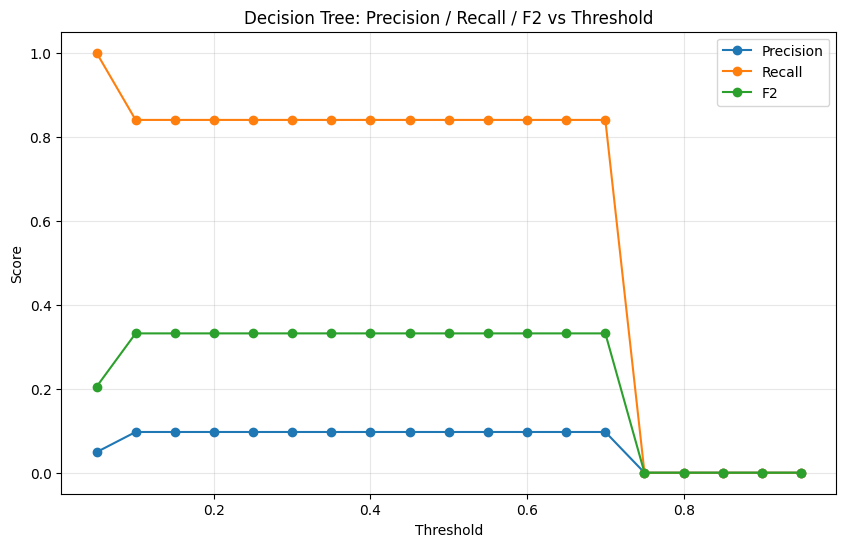

,threshold,precision,recall,f2
1,0.10,0.096998,0.84,0.331754
2,0.15,0.096998,0.84,0.331754
3,0.20,0.096998,0.84,0.331754
11,0.60,0.096998,0.84,0.331754
4,0.25,0.096998,0.84,0.331754
5,0.30,0.096998,0.84,0.331754
6,0.35,0.096998,0.84,0.331754
7,0.40,0.096998,0.84,0.331754
8,0.45,0.096998,0.84,0.331754
9,0.50,0.096998,0.84,0.331754


In [23]:
y_proba = best_tree.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.05, 0.96, 0.05)
rows = []

for thr in thresholds:
    y_pred_thr = (y_proba >= thr).astype(int)
    rows.append({
        "threshold": thr,
        "precision": precision_score(y_test, y_pred_thr, zero_division=0),
        "recall": recall_score(y_test, y_pred_thr, zero_division=0),
        "f2": fbeta_score(y_test, y_pred_thr, beta=2, zero_division=0),
    })
thr_df = pd.DataFrame(rows)

plt.figure(figsize=(10, 6))
plt.plot(thr_df["threshold"], thr_df["precision"], marker="o", label="Precision")
plt.plot(thr_df["threshold"], thr_df["recall"], marker="o", label="Recall")
plt.plot(thr_df["threshold"], thr_df["f2"], marker="o", label="F2")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Decision Tree: Precision / Recall / F2 vs Threshold")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

thr_df.sort_values("f2", ascending=False).head(10)

- Wnioski:
Dla progów do 0.7 metryki są stałe, powyżej jest nagły spadek do zera, co świadczy o tym, że model przestaje przewidywać klasę pozytywną.

## 7.4 SVM

In [24]:
svm = SVC(random_state=42)

param_grid = [
    {
        'kernel': ['linear'],
        'C': [0.01, 0.1, 1, 10, 100],
        'class_weight': ['balanced']
    },
    {
        'kernel': ['rbf'],
        'C': [0.01, 0.1, 1, 10, 100],
        'gamma': ['scale', 'auto', 0.005, 0.1, 1, 5],
        'class_weight': ['balanced']
        #, {0: 1, 1: 50}, {0: 1, 1: 100}
    }
]


scoring_metrics = {
    'custom': custom_scorer,
    'recall': 'recall',
    'precision': 'precision',
    'f2': f2_scorer,
    'roc_auc': 'roc_auc'
}

grid_search = GridSearchCV(
    estimator=svm,
    param_grid=param_grid,
    cv=cv,
    scoring=scoring_metrics,
    refit='recall',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)


Fitting 5 folds for each of 35 candidates, totalling 175 fits


/home/wikmal/2_semestr/ml_laborki/lista-4-projekt-grupowy-malinki-wiki/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/wikmal/2_semestr/ml_laborki/lista-4-projekt-grupowy-malinki-wiki/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/wikmal/2_semestr/ml_laborki/lista-4-projekt-grupowy-malinki-wiki/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted sampl

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC(random_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'C': [0.01, 0.1, ...], 'class_weight': ['balanced'], 'kernel': ['linear']}, {'C': [0.01, 0.1, ...], 'class_weight': ['balanced'], 'gamma': ['scale', 'auto', ...], 'kernel': ['rbf']}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'custom': make_scorer(c...hod='predict'), 'f2': make_scorer(f...ro_division=0), 'precision': 'precision', 'recall': 'recall', ...}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'recall'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` def

In [25]:
best_svm = grid_search.best_estimator_
print(f"best parameters: {grid_search.best_params_}")
print("best score:", grid_search.best_score_) #wynik recall na danych treningowych

svm_metrics = evaluate_model(best_svm, X_train, y_train, X_test, y_test) #wynik recall na danych testowych
print(svm_metrics)

y_pred_test = best_svm.predict(X_test)
test_utility = custom_metric(y_test, y_pred_test)
print(f"Custom Score: {test_utility:.2f}")

best parameters: {'C': 0.01, 'class_weight': 'balanced', 'gamma': 'auto', 'kernel': 'rbf'}
best score: 0.939871794871795
{'recall': 0.84, 'precision': 0.10047846889952153, 'f2': 0.33980582524271846, 'roc_auc': 0.8364609053497942, 'pr_auc': 0.23980266345020654}
Custom Score: -52.00


### 7.5 Regresja logistyczna

In [35]:
f2_scorer_lr = make_scorer(fbeta_score, beta=2, zero_division=0)

cv_lr = StratifiedKFold(n_splits=5, shuffle=True, random_state=67)

lr_base = LogisticRegression(random_state=67, max_iter=10000)

param_grid_lr = {
    "C": np.logspace(-3, 3, 7),
    "solver": ["saga"],
    "class_weight": [None, "balanced"],
}

logreg_search = GridSearchCV(
    estimator=lr_base,
    param_grid=param_grid_lr,
    scoring={
        "recall": "recall",
        "precision": "precision",
        "f2": f2_scorer_lr,
        "custom_scorer": custom_scorer,
    },
    cv=cv_lr,
    refit="recall",
    n_jobs=-1,
    verbose=1,
)

logreg_search.fit(X_train_smote, y_train_smote)

print("Najlepsze parametry:", logreg_search.best_params_)
print("Najlepszy recall (CV):", logreg_search.best_score_)

best_logreg = logreg_search.best_estimator_
logreg_metrics = evaluate_model(
    best_logreg, X_train_smote, y_train_smote, X_test, y_test
)
print("Metryki na teście:", logreg_metrics)

y_pred_lr = best_logreg.predict(X_test)
print("Utility (custom_metric) na teście:", custom_metric(y_test, y_pred_lr))


Fitting 5 folds for each of 14 candidates, totalling 70 fits
Najlepsze parametry: {'C': np.float64(0.1), 'class_weight': None, 'solver': 'saga'}
Najlepszy recall (CV): 0.8801781950882208
Metryki na teście: {'recall': 0.72, 'precision': 0.1925133689839572, 'f2': 0.46511627906976744, 'roc_auc': 0.8311111111111111, 'pr_auc': 0.20888880051136963}
Utility (custom_metric) na teście: -1.75


In [38]:
tu = pd.DataFrame([{"model": "logreg_po_tuningu", **logreg_metrics}])
tu["custom_score"] = custom_metric(y_test, best_logreg.predict(X_test))

print("Porównanie: baseline vs po tuningu")
display(pd.concat([bl, tu], ignore_index=True))


Porównanie: baseline vs po tuningu


,model,recall,precision,f2,roc_auc,pr_auc,custom_score
0,logreg_default,0.64,0.211921,0.455840,0.824403,0.194964,2.25
1,logreg_po_tuningu,0.72,0.192513,0.465116,0.831111,0.208889,-1.75


Tuning podniósł recall i F2 oraz AUC przy lekkim spadku precision; przy domyślnym progu 0.5 rośnie liczba fałszywych alarmów, więc custom_score spada.

### 7.6 Wykresy i analiza błędów 

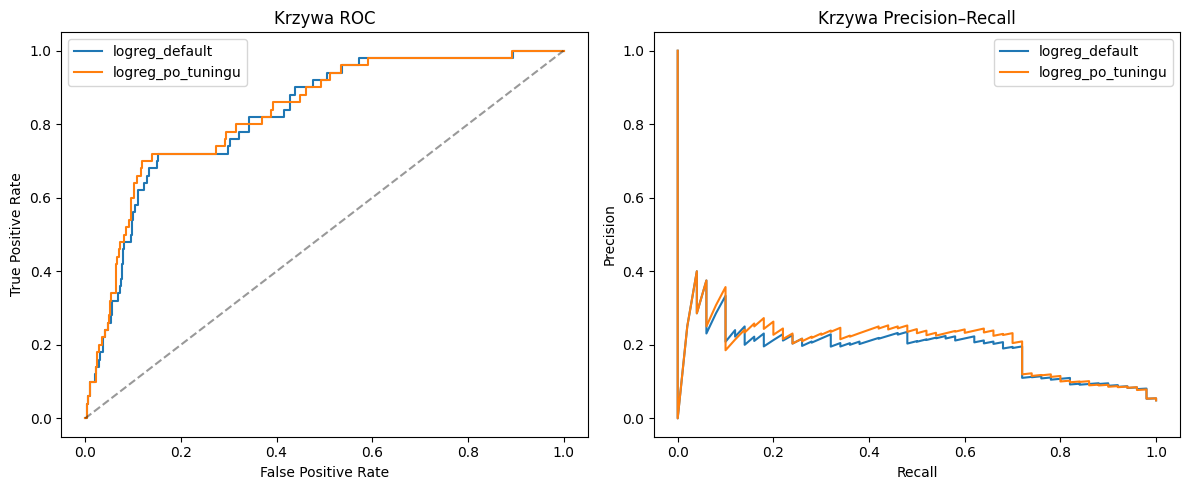

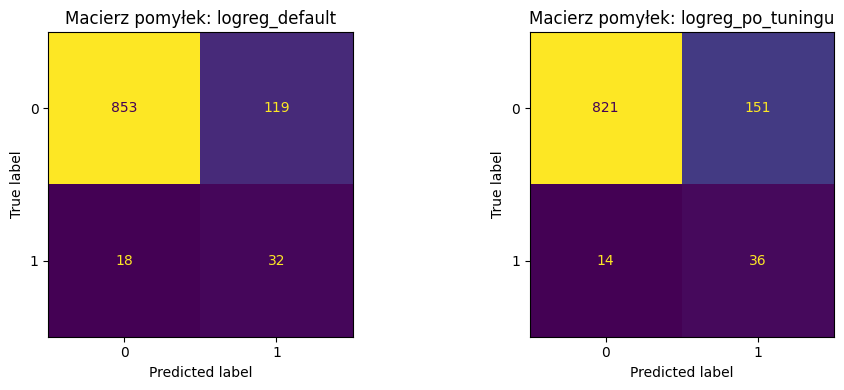

In [39]:
from sklearn.metrics import roc_curve, precision_recall_curve, ConfusionMatrixDisplay

logreg_default = baseline_models["logreg_default"]
logreg_tuned = best_logreg

p_default = logreg_default.predict_proba(X_test)[:, 1]
p_tuned = logreg_tuned.predict_proba(X_test)[:, 1]

y_pred_default = (p_default >= 0.5).astype(int)
y_pred_tuned = (p_tuned >= 0.5).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))


fpr_d, tpr_d, _ = roc_curve(y_test, p_default)
fpr_t, tpr_t, _ = roc_curve(y_test, p_tuned)
axes[0].plot(fpr_d, tpr_d, label="logreg_default")
axes[0].plot(fpr_t, tpr_t, label="logreg_po_tuningu")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[0].set_title("Krzywa ROC")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()

prec_d, rec_d, _ = precision_recall_curve(y_test, p_default)
prec_t, rec_t, _ = precision_recall_curve(y_test, p_tuned)
axes[1].plot(rec_d, prec_d, label="logreg_default")
axes[1].plot(rec_t, prec_t, label="logreg_po_tuningu")
axes[1].set_title("Krzywa Precision–Recall")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_default, ax=axes[0], colorbar=False)
axes[0].set_title("Macierz pomyłek: logreg_default")
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_tuned, ax=axes[1], colorbar=False)
axes[1].set_title("Macierz pomyłek: logreg_po_tuningu")
plt.tight_layout()
plt.show()

Model strojony zmniejsza liczbę FN, więc lepiej wykrywa udary (większy koszt przegapienia) kosztem większej liczby alarmów pozytywnych (więcej dodatkowych badań) — to widać w macierzy pomyłek i jako spadek precision przy wyższym recall.

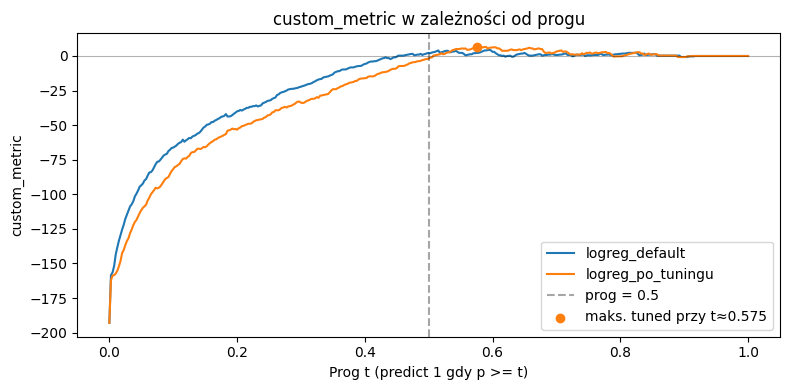

Prog 0.5 (najbliższy punkt siatki) vs najlepszy prog dla strojonej logreg:


,model,t,custom_metric_przy_0_5,t_najlepsze_dla_tuned,custom_metric_przy_najlepszym_tuned
0,logreg_default,0.5,2.25,—,—
1,logreg_po_tuningu,0.5,-1.75,0.575,6.75


In [42]:
def custom_metric_vs_threshold(y_true, p_pos, thresholds):
    """Dla każdego progu t: klasa 1 jeśli p_pos >= t."""
    y_true = np.asarray(y_true)
    p_pos = np.asarray(p_pos)
    scores = []
    for t in thresholds:
        y_hat = (p_pos >= t).astype(int)
        scores.append(custom_metric(y_true, y_hat))
    return np.array(scores)


thresholds = np.linspace(0.0, 1.0, 401)

cm_default = custom_metric_vs_threshold(y_test, p_default, thresholds)
cm_tuned = custom_metric_vs_threshold(y_test, p_tuned, thresholds)

plt.figure(figsize=(8, 4))
plt.plot(thresholds, cm_default, label="logreg_default")
plt.plot(thresholds, cm_tuned, label="logreg_po_tuningu")
plt.axhline(0, color="k", lw=0.8, alpha=0.3)
plt.axvline(0.5, color="k", linestyle="--", alpha=0.35, label="prog = 0.5")

i_best = np.argmax(cm_tuned)
t_best = float(thresholds[i_best])
plt.scatter([t_best], [cm_tuned[i_best]], color="C1", zorder=5, label=f"maks. tuned przy t≈{t_best:.3f}")

plt.title("custom_metric w zależności od progu")
plt.xlabel("Prog t (predict 1 gdy p >= t)")
plt.ylabel("custom_metric")
plt.legend()
plt.tight_layout()
plt.show()

j05 = int(np.argmin(np.abs(thresholds - 0.5)))

tbl = pd.DataFrame(
    {
        "model": ["logreg_default", "logreg_po_tuningu"],
        "t": [0.5, 0.5],
        "custom_metric_przy_0_5": [float(cm_default[j05]), float(cm_tuned[j05])],
        "t_najlepsze_dla_tuned": ["—", round(t_best, 4)],
        "custom_metric_przy_najlepszym_tuned": ["—", float(cm_tuned[i_best])],
    }
)

print("Prog 0.5 (najbliższy punkt siatki) vs najlepszy prog dla strojonej logreg:")
display(tbl)

## 8. Ewaluacja modelu końcowego

- Macierz pomyłek i interpretacja.
- Klasyfikacja błędów.
- Analiza cech ważnych dla predykcji.
- Ograniczenia modelu.

W część C porównano baseline i model drzewa decyzyjnego. Najlepszy okazał się `decision_tree_best`. Metryki testowe: recall = 0.84, precision = 0.097, F2 = 0.332, ROC-AUC=0.719, PR-AUC=0.089. Z nieco gorszym recall jest regresja logistyczna: recall = 0.72, ale za to ma najlepszy custom score ze wszystkich, tj. -1.75.

```diff
- TO DO: Wyniki logreg, SVM, Kuba, Wiktoria

## 9. Wnioski i dalsze kroki

- Podsumowanie najważniejszych rezultatów.
- Odpowiedź na pytanie badawcze.
- Propozycje ulepszeń.
- Pomysły na dalszą pracę.

Drzewo dało najwyższy recall i F2 spośród modeli osoby C.
Koszt to niska precyzja, czyli dużo fałszwych alarmów, lecz zgodnie z metryką biznesową model predykuje zagrożenie życia.
Analiza thresholdu ukazała skokowy charakter predykcji, czyli prostotę modelu drzewa.


```diff
- TO DO : Wyniki i wnioski z SVM oraz Logreg 